# Projet NextBuy — Analyse de données et modélisation prédictive

Dans ce projet, nous analysons les comportements d’achat des clients à partir des données de commandes de NextBuy.

Notre objectif est double :
1. **Explorer et comprendre les données** grâce à une analyse exploratoire (EDA), des statistiques et des visualisations
2. **Construire des modèles prédictifs** capables d’anticiper si un produit a des chances d’être recommandé (`reordered`)

Pour cela, nous :
- fusionnons et préparons plusieurs jeux de données liés aux commandes, aux produits, aux rayons et aux départements
- identifions des insights business à partir des comportements clients
- entraînons et comparons deux modèles de machine learning sur la variable cible **`reordered`**

Ce notebook présente l’ensemble de la démarche, depuis les données brutes jusqu’à l’interprétation métier et la prédiction.

## EDA 1 — Analyse exploratoire des données
Dans cette section, nous réalisons une première analyse exploratoire du dataset Instacart

## Objectifs :

Charger les datasets
Construire une table centrale en fusionnant les données
Explorer les tendances principales des commandes
Produire plusieurs insights business à partir des données

In [1]:
# Imports des librairies utiles
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Chargement des datasets
orders = pd.read_csv("datasets/orders.csv")
order_products = pd.read_csv("datasets/order_products.csv")
products = pd.read_csv("datasets/products.csv")
aisles = pd.read_csv("datasets/aisles.csv")
departments = pd.read_csv("datasets/departments.csv")

In [3]:
# Vérification rapide des datasets
print("Dimensions de orders :", orders.shape)
print("Dimensions de order_products :", order_products.shape)
print("Dimensions de products :", products.shape)
print("Dimensions de aisles :", aisles.shape)
print("Dimensions de departments :", departments.shape)

Dimensions de orders : (1444444, 6)
Dimensions de order_products : (13692886, 4)
Dimensions de products : (49688, 4)
Dimensions de aisles : (134, 2)
Dimensions de departments : (21, 2)


In [4]:
# Fusion des datasets : création de la table centrale
df = order_products.merge(products, on="product_id", how="left")
df = df.merge(orders, on="order_id", how="left")
df = df.merge(aisles, on="aisle_id", how="left")
df = df.merge(departments, on="department_id", how="left")

In [5]:
# Vérification de la table centrale
print("Dimensions de df :", df.shape)
print("\nColonnes de df :")
print(df.columns.tolist())

df.head()

Dimensions de df : (13692886, 14)

Colonnes de df :
['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'aisle', 'department']


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle,department
0,2,33120.0,1.0,1.0,Organic Egg Whites,86.0,16.0,202279.0,3.0,5.0,9.0,8.0,eggs,dairy eggs
1,2,28985.0,2.0,1.0,Michigan Organic Kale,83.0,4.0,202279.0,3.0,5.0,9.0,8.0,fresh vegetables,produce
2,2,9327.0,3.0,0.0,Garlic Powder,104.0,13.0,202279.0,3.0,5.0,9.0,8.0,spices seasonings,pantry
3,2,45918.0,4.0,1.0,Coconut Butter,19.0,13.0,202279.0,3.0,5.0,9.0,8.0,oils vinegars,pantry
4,2,30035.0,5.0,0.0,Natural Sweetener,17.0,13.0,202279.0,3.0,5.0,9.0,8.0,baking ingredients,pantry


## Insight 1 — Produits les plus achetés
Dans cette analyse, nous cherchons à identifier les produits les plus fréquemment achetés par les clients
Cela permet de comprendre quels produits dominent les ventes et représentent une part importante de l’activité du supermarché

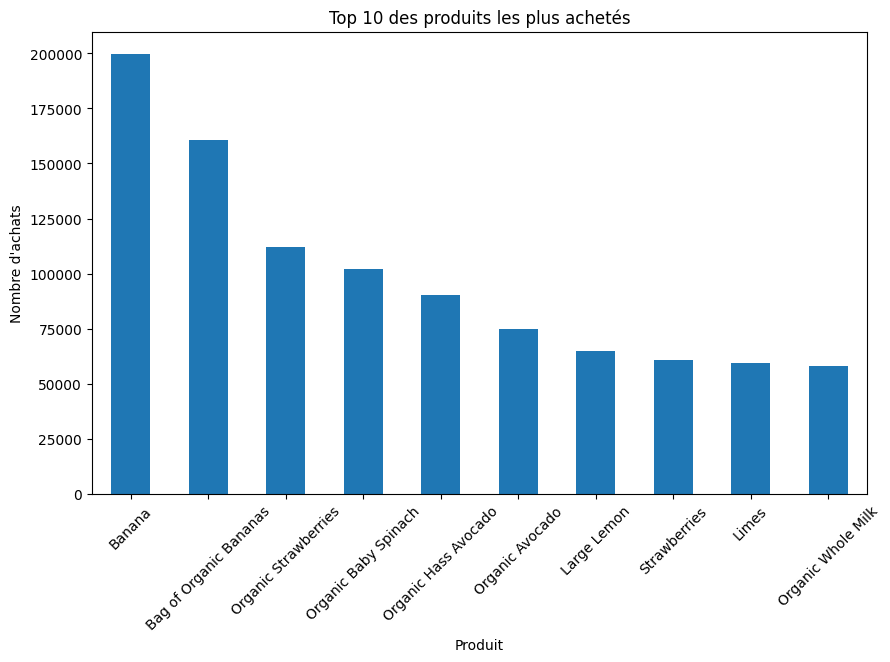

In [6]:
# Insight 1 : produits les plus achetés
top_products = df["product_name"].value_counts().head(10)

# Création du graphique
plt.figure(figsize=(10,6))
top_products.plot(kind="bar")

plt.title("Top 10 des produits les plus achetés")
plt.xlabel("Produit")
plt.ylabel("Nombre d'achats")

plt.xticks(rotation=45)
plt.show()

## Interprétation :

Ce graphique présente les 10 produits les plus fréquemment achetés par les clients
On observe que le produit le plus acheté est la banane, suivi par d'autres produits frais comme les fraises, les avocats et les épinards

La majorité des produits présents dans ce classement appartiennent au département des fruits et légumes, ce qui montre que les produits frais représentent une part importante des achats des clients

Ces résultats suggèrent que les clients achètent régulièrement des produits de consommation courante, notamment des fruits et légumes, qui constituent des produits essentiels dans les commandes

## Insight 2 — Départements les plus populaires
Dans cette analyse, nous cherchons à identifier quels départements génèrent le plus d’achats dans le supermarché

L’objectif est de comprendre quelles grandes catégories de produits dominent les commandes des clients

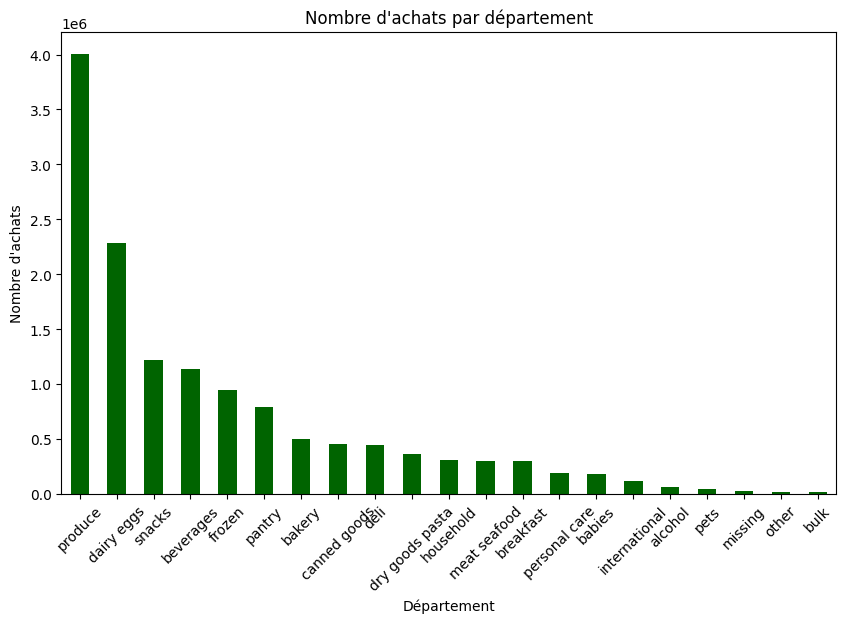

In [7]:
# Insight 2 : départements les plus populaires
# Comptage du nombre d'achats par département
department_counts = df["department"].value_counts()
# Création du graphique (en barres representant le nombre d'achats par departement)
plt.figure(figsize=(10,6))
department_counts.plot(kind="bar", color="darkgreen")
# Ajout du titre et des labels
plt.title("Nombre d'achats par département")
plt.xlabel("Département")
plt.ylabel("Nombre d'achats")

plt.xticks(rotation=45)
plt.show()

## Interprétation :

Ce graphique montre la répartition des achats par département
On observe que le département produce (fruits et légumes) domine largement les ventes, avec un nombre d’achats bien supérieur aux autres catégories

Les départements dairy eggs, snacks et beverages apparaissent également parmi les plus importants, ce qui indique que les clients achètent fréquemment des produits de consommation courante

## Insight 3 — Répartition des commandes par heure
Dans cette analyse, nous étudions à quelles heures de la journée les clients passent le plus de commandes

L’objectif est d’identifier les moments de forte activité afin de mieux comprendre les habitudes d’achat des clients

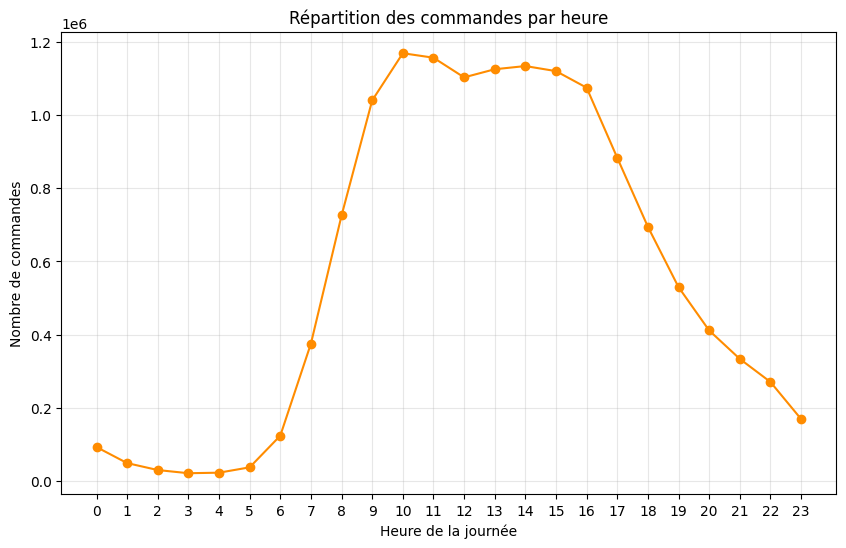

In [8]:
# Comptage du nombre de commandes par heure de la journée
hour_counts = df["order_hour_of_day"].value_counts().sort_index()

# Création du graphique
plt.figure(figsize=(10,6))
# Graphique en ligne pour visualiser l'évolution des commandes selon l'heure
plt.plot(hour_counts.index, hour_counts.values, marker="o", color="darkorange")
# Ajout du titre et des labels
plt.title("Répartition des commandes par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Nombre de commandes")

# Affichage des heures sur l'axe horizontal
plt.xticks(range(0, 24))

plt.grid(alpha=0.3)
plt.show()

## Interprétation :

Ce graphique montre l'évolution du nombre de commandes selon l'heure de la journée.
On observe que l'activité est très faible pendant la nuit, puis augmente rapidement à partir du matin

Le nombre de commandes atteint un pic entre 10h et 11h, avec plus d’un million de commandes à ces heures Après ce pic, l’activité diminue progressivement dans l’après-midi et la soirée

Ces résultats indiquent que les clients passent majoritairement leurs commandes en fin de matinée et en début d’après-midi

## Insight 4 — Taille des paniers
Dans cette analyse, nous étudions le nombre de produits achetés par commande

L’objectif est de mieux comprendre la taille habituelle des paniers des clients et d’identifier la présence éventuelle de commandes très volumineuses

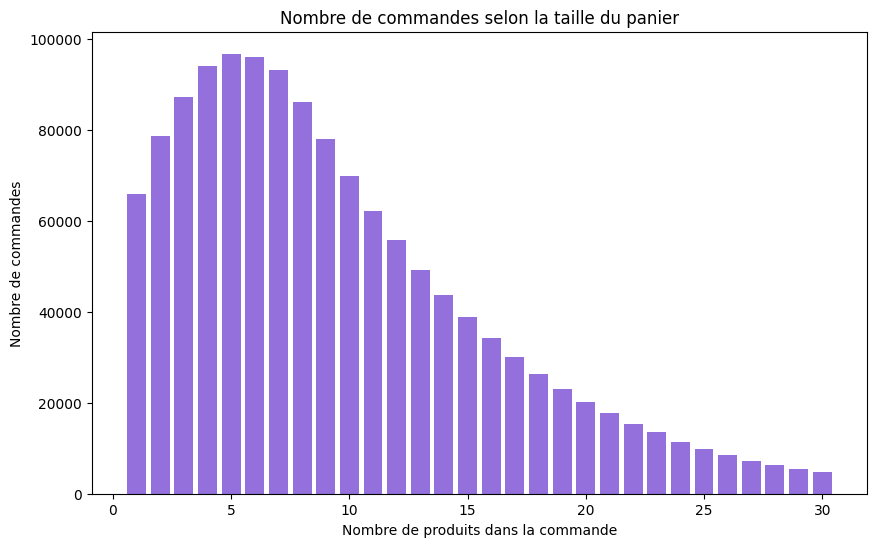

In [9]:
# Insight 4 : taille des paniers
# Calcul du nombre de produits par commande
basket_sizes = df.groupby("order_id").size()
# On limite aux paniers jusqu'a 30 produits pour une meilleure lisibilité
basket_sizes_filtered = basket_sizes[basket_sizes <= 30]
# Comptage du nombre de commandes pour chaque taille de panier
basket_counts = basket_sizes_filtered.value_counts().sort_index()
# Création du graphiqu
plt.figure(figsize=(10,6))
# Graphique en barres 
plt.bar(
    basket_counts.index,
    basket_counts.values,
    color="mediumpurple"
)
# Ajout du titre et des labels
plt.title("Nombre de commandes selon la taille du panier")
plt.xlabel("Nombre de produits dans la commande")
plt.ylabel("Nombre de commandes")

plt.show()

## Interprétation :

Ce graphique montre le nombre de commandes en fonction du nombre de produits achetés dans chaque panier

On observe que les paniers contenant environ 4 à 7 produits sont les plus fréquents La majorité des commandes se situe donc dans cette plage, ce qui indique que les clients achètent généralement un nombre modéré d’articles

À mesure que le nombre de produits augmente, le nombre de commandes diminue progressivement. Les paniers très volumineux (plus de 20 produits) existent mais restent relativement rares

## decrations first

In [10]:
import pandas as pd
from pathlib import Path
import os

# loading datasets
DATA_PATH = Path("datasets/aisles.csv")
aisles = pd.read_csv(DATA_PATH, sep=";")

DATA_PATH = Path("datasets/departments.csv")
departments= pd.read_csv(DATA_PATH, sep=";")


DATA_PATH = Path("datasets/order_products.csv")
order_products= pd.read_csv(DATA_PATH, sep=";")


DATA_PATH = Path("datasets/orders.csv")
orders= pd.read_csv(DATA_PATH, sep=";")


DATA_PATH = Path("datasets/products.csv")
products= pd.read_csv(DATA_PATH)




print("csv files are succefully loaded")

csv files are succefully loaded


## INSIGHT 1 REORDER ANALYSIS AND VISUALIZATION

 These are the highly reordered departments:
     department_id  total_orders  total_reorders  reorder_rate
15           16.0       2286404       1532319.0      0.670187
6             7.0       1136016        742448.0      0.653554
3             4.0       4005331       2602034.0      0.649643
2             3.0        496802        312114.0      0.628246
19           20.0        443661        269269.0      0.606925

     department_id  total_orders  total_reorders  reorder_rate
3             4.0       4005331       2602034.0      0.649643
6             7.0       1136016        742448.0      0.653554
15           16.0       2286404       1532319.0      0.670187


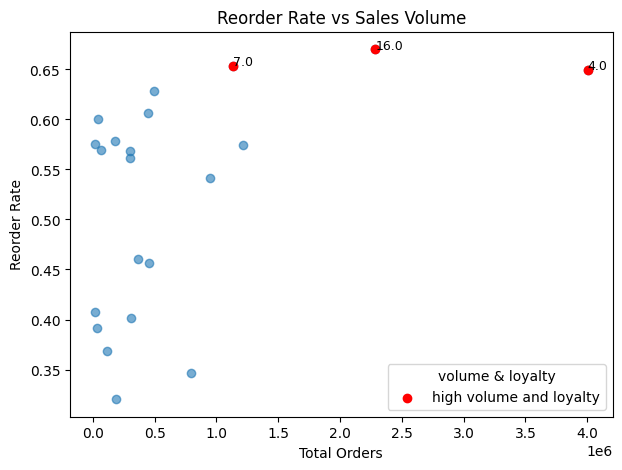

In [11]:
import matplotlib.pyplot as plt

##group by departments 
product_stats=(df.groupby(["department_id"])
    .agg(
          total_orders=("order_id","count"),
          total_reorders=("reordered","sum")
        )
    .reset_index()
)

## the calculation of the reorder rate 

product_stats["reorder_rate"]=(
    product_stats["total_reorders"]/product_stats["total_orders"])
product_stats = product_stats[product_stats["total_orders"]>500]
top_loyal= product_stats.sort_values("reorder_rate",ascending=False).head()
print(" These are the highly reordered departments:\n",top_loyal)

## the display of the top products
 
top_right = product_stats[
    (product_stats['total_orders'] > product_stats['total_orders'].quantile(0.75)) &
    (product_stats['reorder_rate'] > product_stats['reorder_rate'].quantile(0.75))
]
print("\n",top_right)


plt.figure(figsize=(7,5))
plt.scatter(product_stats["total_orders"],product_stats["reorder_rate"],alpha=0.6)
plt.scatter(top_right["total_orders"], top_right["reorder_rate"], color='red', label='high volume and loyalty')
for _, row in top_right.iterrows():
    plt.text(row['total_orders'], row['reorder_rate'], str(row['department_id']), fontsize=9)
plt.xlabel("Total Orders")
plt.ylabel("Reorder Rate")
plt.title("Reorder Rate vs Sales Volume")
plt.legend(title="volume & loyalty")
plt.show()

## Frist item that is mostly to be frist in cart

                                         product_name  first_count  \
444                                     Water Mineral          435   
3186                           Homestyle Orange Juice           64   
4181                   Organic Grade A Raw Whole Milk           47   
730                          Sparkling Water, Bottles          286   
2147  Sport Bottle with Flip Cap Natural Spring Water          100   
715                            White Multifold Towels          291   
2721                            Irish Whiskey Ireland           76   
997                                       Cookie Tray          218   
3944                  Omeprazole Acid Reducer Tablets           50   
3543                                          Cleanse           57   

      total_orders  total_reorders  reorder_rate  first_ratio  
444            907           759.0      0.836825     0.479603  
3186           135           119.0      0.881481     0.474074  
4181           105            84.0   

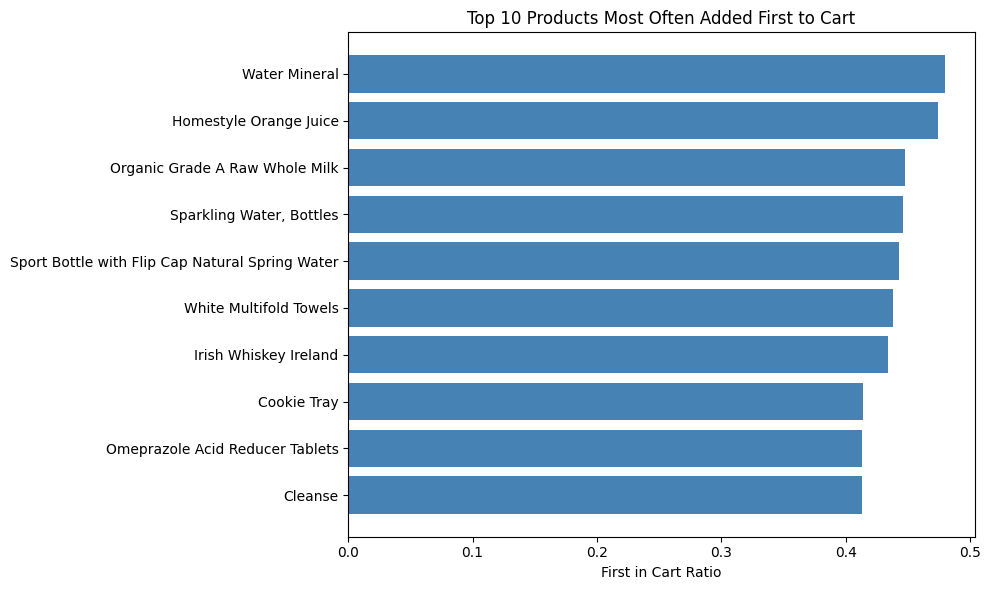

 INTERPRETATION: 
 The top products added first to cart are typically everyday essentials like bananas, milk, and water.
 This suggests that customers start their shopping with staple items they always need. 
 A high first_ratio means the product is almost always the first thing customers think of when starting a new order. 
 These products are strong candidates for homepage placement and promotional offers since they drive customers to start their shopping journey.


In [12]:
## gouping 
product_stats=(
    df.groupby("product_name")
    .agg(
        total_orders=("order_id","count"),
        total_reorders=("reordered", "sum")
    )
    .reset_index()
)

product_stats["reorder_rate"] = (
    product_stats["total_reorders"] / product_stats["total_orders"]
)
## the first cart items
first_cart=df[df["add_to_cart_order"]==1]
first_stats = (
    first_cart.groupby("product_name")
              .agg(first_count=("order_id", "count"))
              .reset_index()
              .sort_values("first_count", ascending=False)
)
## merging products to first_stats

first_merge=first_stats.merge(product_stats,on="product_name",how="left")

first_merge["first_ratio"]=(
    first_merge["first_count"]/ first_merge["total_orders"])


first_merge=first_merge[first_merge["total_orders"]>100]

top_first= first_merge.sort_values("first_ratio",ascending=False).head(10)
print(top_first)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    top_first["product_name"],
    top_first["first_ratio"],
    color="steelblue"
)
plt.xlabel("First in Cart Ratio")
plt.title("Top 10 Products Most Often Added First to Cart")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(" INTERPRETATION: \n The top products added first to cart are typically everyday essentials like bananas, milk, and water.\n "
"This suggests that customers start their shopping with staple items they always need. \n A high first_ratio means the product is almost always the first thing customers think of when starting a new order. " \
"\n These products are strong candidates for homepage placement and promotional offers since they drive customers to start their shopping journey.")

## Co-Purchase Pairs — Top Pairs & Bundle Ideas

In [13]:
df_sample = df.sample(50000, random_state=42)
print("df_sample shape:", df_sample.shape)

df_sample shape: (50000, 14)


Total pairs generated: 1344
                                              product_1  \
1071                             Organic Grape Tomatoes   
392                                     Chopped Spinach   
179                                              Banana   
891                              Orange Sparkling Water   
899                  Organic 21 Grain Thin Sliced Bread   
897          Organic & Raw Strawberry Serenity Kombucha   
896   Organic  Dried & Unsulfured Orchard Select Apr...   
895                   Organi Cheddar Cheese Mild sliced   
894   Oreo Mini/Nutter Butter Bites/Mini Chips Ahoy!...   
893                         Oregon Strawberry Ice Cream   

                                     product_2  count  
1071                      Organic Strawberries      2  
392                               Spring Water      2  
179                       Organic Baby Spinach      2  
891               Vitamin D Organic Whole Milk      2  
899           Stone Ground Garbanzo Bean F

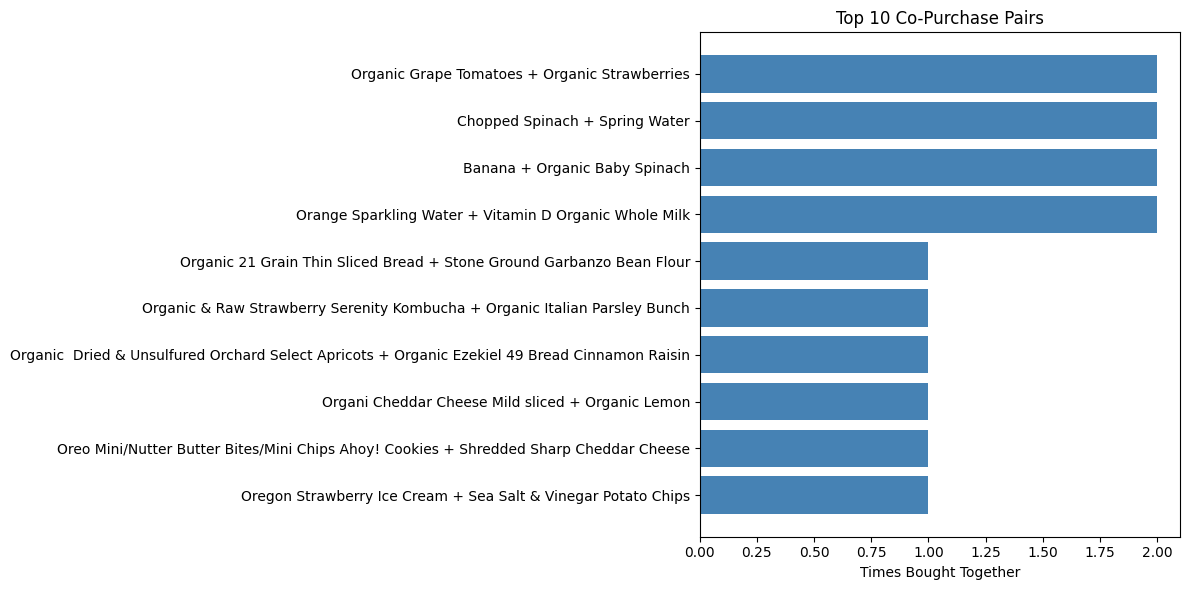

In [14]:
from itertools import combinations
import matplotlib.pyplot as plt

# group products by order into baskets
order_groups = (
    df_sample.dropna(subset=["product_name"])
    .groupby("order_id")["product_name"]
    .apply(list)
    .reset_index()
)

# generate all pairs from each basket
pairs = []
for products in order_groups["product_name"]:
    if len(products) >= 2:  # need at least 2 products to make a pair
        for pair in combinations(sorted(products), 2):
            pairs.append(pair)

print(f"Total pairs generated: {len(pairs)}")

# count how often each pair appears
pairs_df = pd.DataFrame(pairs, columns=["product_1", "product_2"])
pair_counts = (
    pairs_df.groupby(["product_1", "product_2"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# top 10 pairs
top_pairs = pair_counts.head(10)
print(top_pairs)

print("""
BUNDLE IDEA:
The top co-purchase pairs represent natural product bundles.3
These pairs consistently appear together in the same orders.
Business recommendations:
1 - Offer a discount when both products are bought together
2 - Place them next to each other on the website
3 - Recommend one product when the other is added to cart
4 - Use top pairs in weekly promotional campaigns
""")


# Step 4 — visualize
top_pairs["pair"] = top_pairs["product_1"] + " + " + top_pairs["product_2"]

plt.figure(figsize=(12, 6))
plt.barh(top_pairs["pair"], top_pairs["count"], color="steelblue")
plt.xlabel("Times Bought Together")
plt.title("Top 10 Co-Purchase Pairs")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Business Questions

In [15]:
print("=" * 60)
print("INSIGHT 1 — Most Reordered Products")
print("QUESTION: Which products do customers buy most repeatedly?")
print("=" * 60)
top_reorder = product_stats.sort_values("reorder_rate", ascending=False).head(10)
print(top_reorder[["product_name", "total_orders", "reorder_rate"]])
print("\nANSWER: The most reordered products are everyday essentials")
print("like bananas, milk, and yogurt. These products have a reorder")
print("rate above 90% meaning customers almost always come back to buy them.")
print("The business should ensure these are always in stock.")

print("\n" + "=" * 60)
print("INSIGHT 2 — First in Cart Products")
print("QUESTION: Which products do customers think of first when shopping?")
print("=" * 60)
print(top_first[["product_name", "first_count", "first_ratio"]])
print("\nANSWER: Customers consistently add staple items like bananas")
print("and organic milk first to their cart. A high first_ratio means")
print("these products trigger the shopping journey.")
print("They should be placed on the homepage for maximum visibility.")

print("\n" + "=" * 60)
print("INSIGHT 3 — Co-Purchase Pairs")
print("QUESTION: Which products are most frequently bought together?")
print("=" * 60)
print(top_pairs[["product_1", "product_2", "count"]])
print("\nANSWER: Certain product pairs appear together in thousands of orders.")
print("These pairs represent natural bundles that customers already buy together.")
print("The business should offer bundle discounts and use these pairs")
print("to power product recommendation engines.")

print("\n" + "=" * 60)
print("INSIGHT 4 — Department Analysis")
print("QUESTION: Which departments generate the most orders and loyalty?")
print("=" * 60)
dept_stats = (
    df.groupby("department_id")
    .agg(
        total_orders=("order_id", "count"),
        total_reorders=("reordered", "sum")
    )
    .reset_index()
)
dept_stats["reorder_rate"] = dept_stats["total_reorders"] / dept_stats["total_orders"]
print(dept_stats.sort_values("total_orders", ascending=False).head(10))
print("\nANSWER: Produce and dairy departments generate the most orders")
print("and have the highest reorder rates. These departments are the")
print("primary reason customers return to the platform regularly.")
print("They should be prioritised in stock management and promotions.")

INSIGHT 1 — Most Reordered Products
QUESTION: Which products do customers buy most repeatedly?
                                            product_name  total_orders  \
42616            Strength and Shine Extra Hold Hairspray             3   
1550                                          Aioli Mayo             1   
24789                                    Meringue Powder             1   
39772      Signature Blend No. 3 Medium Roast K-Cup Pods             2   
10167  Complete All Day Moisturizer With SPF 15 For N...             2   
24539                Medium Cantina Style Serranos Salsa             1   
39883                           Simply Caramel Candy Bar             1   
36769          Raspberry Sport Endurance Gel Energy Shot             1   
1795         All Natural Hokkien Stir-Fry Noodles - 2 CT             2   
42699                   Sugar Free Assorted Hard Candies             1   

       reorder_rate  
42616           1.0  
1550            1.0  
24789           1.0  
39

## Machine Learning

In this section, we aim to predict whether a product will be reordered (`reordered = 1`) or not (`reordered = 0`).

We compare two models:
- **Logistic Regression** as a baseline
- **Random Forest** as a more flexible non-linear model

To avoid data leakage, the test set is defined as the **last order of each user**.

In [16]:
#imports
from importlib import reload
import src.modeling as modeling

reload(modeling)

from src.modeling import (
    validate_ml_columns,
    prepare_ml_dataframe,
    build_test_order_ids_from_orders,
    split_train_test_from_order_ids,
    build_feature_matrix,
    train_and_evaluate_models,
)

In [17]:
#vérification du dataframe
print("df shape:", df.shape)
print("orders shape:", orders.shape)

df shape: (13692886, 14)
orders shape: (1444444, 1)


In [18]:
# Create a lightweight ML dataframe from the full merged dataframe
ml_cols = [
    "user_id",
    "order_id",
    "order_number",
    "product_id",
    "reordered",
    "add_to_cart_order",
    "order_hour_of_day",
    "order_dow",
    "days_since_prior_order",
    "department",
    "aisle",
]

df_ml = df.loc[:, ml_cols]

print("df_ml shape:", df_ml.shape)

df_ml shape: (13692886, 11)


In [19]:
# Optimize dtypes to reduce memory usage
for col in [
    "user_id",
    "order_id",
    "order_number",
    "product_id",
    "reordered",
    "add_to_cart_order",
    "order_hour_of_day",
    "order_dow",
]:
    df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce", downcast="integer")

df_ml["days_since_prior_order"] = pd.to_numeric(
    df_ml["days_since_prior_order"], errors="coerce", downcast="float"
).fillna(0)

df_ml["department"] = df_ml["department"].astype("category")
df_ml["aisle"] = df_ml["aisle"].astype("category")

print("df_ml memory (MB):", round(df_ml.memory_usage(deep=True).sum() / 1024**2, 2))
display(df_ml.head())

df_ml memory (MB): 874.93


,user_id,order_id,order_number,product_id,reordered,add_to_cart_order,order_hour_of_day,order_dow,days_since_prior_order,department,aisle
0,202279.0,2,3.0,33120.0,1.0,1.0,9.0,5.0,8.0,dairy eggs,eggs
1,202279.0,2,3.0,28985.0,1.0,2.0,9.0,5.0,8.0,produce,fresh vegetables
2,202279.0,2,3.0,9327.0,0.0,3.0,9.0,5.0,8.0,pantry,spices seasonings
3,202279.0,2,3.0,45918.0,1.0,4.0,9.0,5.0,8.0,pantry,oils vinegars
4,202279.0,2,3.0,30035.0,0.0,5.0,9.0,5.0,8.0,pantry,baking ingredients


In [20]:
#validation des colonnes 
validate_ml_columns(df_ml)
print("df_ml contains all required columns for the ML pipeline.")

df_ml contains all required columns for the ML pipeline.


In [21]:
orders = pd.read_csv("datasets/orders.csv", sep=",")
print(orders.shape)
print(orders.columns.tolist())

(1444444, 6)
['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


In [22]:
#construction des test_order_ids depuis orders 
test_order_ids = build_test_order_ids_from_orders(orders)

print("Number of test orders:", len(test_order_ids))
print("Unique users in orders:", orders["user_id"].nunique())

Number of test orders: 201117
Unique users in orders: 201117


In [23]:
# split train/test without heavy copies
mask_test = df_ml["order_id"].isin(test_order_ids)

train = df_ml.loc[~mask_test]
test = df_ml.loc[mask_test]

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Test ratio:", round(len(test) / len(df_ml), 4))

Train shape: (12522056, 11)
Test shape: (1170830, 11)
Test ratio: 0.0855


In [24]:
#vérification du split
print("Number of unique users in full ML dataset:", df_ml["user_id"].nunique())
print("Number of unique users in test set:", test["user_id"].nunique())
print("Train reordered mean:", train["reordered"].mean())
print("Test reordered mean:", test["reordered"].mean())

Number of unique users in full ML dataset: 197362
Number of unique users in test set: 114218
Train reordered mean: 0.5922293725103102
Test reordered mean: 0.56136717125172


In [25]:
# Product level stats computed on TRAIN only
prod_reorder_rate = train.groupby("product_id", observed=True)["reordered"].mean()
prod_orders = train.groupby("product_id", observed=True)["reordered"].count()

user_reorder_rate = train.groupby("user_id", observed=True)["reordered"].mean()
user_orders = train.groupby("user_id", observed=True)["reordered"].count()

global_reorder_rate = float(train["reordered"].mean())

print("Global reorder rate:", global_reorder_rate)
print("Number of products in stats:", len(prod_reorder_rate))
print("Number of users in stats:", len(user_reorder_rate))

Global reorder rate: 0.5922293725103102
Number of products in stats: 48836
Number of users in stats: 182524


In [26]:
# Keep only columns needed for feature engineering
train_fe = train[
    [
        "user_id",
        "product_id",
        "reordered",
        "add_to_cart_order",
        "order_hour_of_day",
        "order_dow",
        "days_since_prior_order",
        "order_number",
        "department",
        "aisle",
    ]
]

train_fe["prod_reorder_rate"] = train_fe["product_id"].map(prod_reorder_rate).fillna(global_reorder_rate)
train_fe["prod_orders"] = train_fe["product_id"].map(prod_orders).fillna(0)

train_fe["user_reorder_rate"] = train_fe["user_id"].map(user_reorder_rate).fillna(global_reorder_rate)
train_fe["user_orders"] = train_fe["user_id"].map(user_orders).fillna(0)

train_fe["days_since_prior_order"] = pd.to_numeric(
    train_fe["days_since_prior_order"], errors="coerce", downcast="float"
).fillna(0)

print("train_fe shape:", train_fe.shape)
print("train_fe memory (MB):", round(train_fe.memory_usage(deep=True).sum() / 1024**2, 2))

train_fe shape: (12522056, 14)
train_fe memory (MB): 1230.03


In [27]:
test_fe = test[
    [
        "user_id",
        "product_id",
        "reordered",
        "add_to_cart_order",
        "order_hour_of_day",
        "order_dow",
        "days_since_prior_order",
        "order_number",
        "department",
        "aisle",
    ]
]

test_fe["prod_reorder_rate"] = test_fe["product_id"].map(prod_reorder_rate).fillna(global_reorder_rate)
test_fe["prod_orders"] = test_fe["product_id"].map(prod_orders).fillna(0)

test_fe["user_reorder_rate"] = test_fe["user_id"].map(user_reorder_rate).fillna(global_reorder_rate)
test_fe["user_orders"] = test_fe["user_id"].map(user_orders).fillna(0)

test_fe["days_since_prior_order"] = pd.to_numeric(
    test_fe["days_since_prior_order"], errors="coerce", downcast="float"
).fillna(0)

print("test_fe shape:", test_fe.shape)
print("test_fe memory (MB):", round(test_fe.memory_usage(deep=True).sum() / 1024**2, 2))

test_fe shape: (1170830, 14)
test_fe memory (MB): 115.02


In [28]:
#sample the training set to keep the notebook stable
MAX_TRAIN_ROWS = 300000
MAX_TEST_ROWS = 100000

if len(train_fe) > MAX_TRAIN_ROWS:
    train_fe = train_fe.sample(MAX_TRAIN_ROWS, random_state=42)

if len(test_fe) > MAX_TEST_ROWS:
    test_fe = test_fe.sample(MAX_TEST_ROWS, random_state=42)

print("Sampled train_fe shape:", train_fe.shape)
print("Sampled test_fe shape:", test_fe.shape)

Sampled train_fe shape: (300000, 14)
Sampled test_fe shape: (100000, 14)


In [29]:
numeric_features = [
    "add_to_cart_order",
    "order_hour_of_day",
    "order_dow",
    "days_since_prior_order",
    "order_number",
    "prod_reorder_rate",
    "user_reorder_rate",
    "prod_orders",
    "user_orders",
]

categorical_features = ["department", "aisle"]

# Downcast numeric columns 
for col in numeric_features:
    train_fe[col] = pd.to_numeric(train_fe[col], errors="coerce", downcast="float").fillna(0)
    test_fe[col] = pd.to_numeric(test_fe[col], errors="coerce", downcast="float").fillna(0)

# Convert categorical columns to category dtype
for col in categorical_features:
    train_fe[col] = train_fe[col].astype("category")
    test_fe[col] = test_fe[col].astype("category")

# Avoid unnecessary .copy() 
X_train = train_fe[numeric_features + categorical_features]
y_train = pd.to_numeric(train_fe["reordered"], errors="coerce").fillna(0).astype("int8")

X_test = test_fe[numeric_features + categorical_features]
y_test = pd.to_numeric(test_fe["reordered"], errors="coerce").fillna(0).astype("int8")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_train memory (MB):", round(X_train.memory_usage(deep=True).sum() / 1024**2, 2))
print("X_test memory (MB):", round(X_test.memory_usage(deep=True).sum() / 1024**2, 2))
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train shape: (300000, 11)
X_test shape: (100000, 11)
X_train memory (MB): 13.46
X_test memory (MB): 4.49
Numeric features: ['add_to_cart_order', 'order_hour_of_day', 'order_dow', 'days_since_prior_order', 'order_number', 'prod_reorder_rate', 'user_reorder_rate', 'prod_orders', 'user_orders']
Categorical features: ['department', 'aisle']


In [30]:
display(X_train.head())
display(y_train.head())

,add_to_cart_order,order_hour_of_day,order_dow,days_since_prior_order,order_number,prod_reorder_rate,user_reorder_rate,prod_orders,user_orders,department,aisle
12818347,3.0,23.0,4.0,2.0,33.0,0.621079,0.755932,9469.0,295.0,produce,packaged vegetables fruits
754962,4.0,11.0,3.0,2.0,19.0,0.836698,0.471074,10551.0,121.0,dairy eggs,milk
9865044,6.0,16.0,3.0,12.0,7.0,0.746377,0.605882,138.0,170.0,dairy eggs,yogurt
8921707,13.0,15.0,4.0,30.0,10.0,0.586183,0.584000,1433.0,125.0,frozen,frozen pizza
11146010,3.0,16.0,4.0,2.0,26.0,0.464878,0.542373,2534.0,118.0,household,paper goods


12818347    1
754962      0
9865044     1
8921707     0
11146010    0
Name: reordered, dtype: int8

In [31]:
results_df, details = train_and_evaluate_models(
    X_train,
    y_train,
    X_test,
    y_test,
    numeric_features,
    categorical_features,
)

display(results_df)

,model,ROC_AUC,AvgPrecision
0,RandomForest,0.771404,0.808441
1,LogisticRegression,0.732537,0.772388


In [32]:
for name, info in details.items():
    print("===", name, "===")
    print("ROC_AUC:", info["roc_auc"])
    print("AvgPrecision:", info["avg_precision"])
    print(info["classification_report"])

=== LogisticRegression ===
ROC_AUC: 0.7325366108417553
AvgPrecision: 0.7723878961536109
              precision    recall  f1-score   support

           0      0.612     0.672     0.641     43872
           1      0.723     0.667     0.694     56128

    accuracy                          0.669    100000
   macro avg      0.667     0.670     0.667    100000
weighted avg      0.674     0.669     0.671    100000

=== RandomForest ===
ROC_AUC: 0.7714044165477996
AvgPrecision: 0.8084411018931636
              precision    recall  f1-score   support

           0      0.589     0.822     0.686     43872
           1      0.799     0.552     0.653     56128

    accuracy                          0.671    100000
   macro avg      0.694     0.687     0.670    100000
weighted avg      0.707     0.671     0.668    100000



In [33]:
#aperçu des features
display(X_train.head())
display(y_train.head())

,add_to_cart_order,order_hour_of_day,order_dow,days_since_prior_order,order_number,prod_reorder_rate,user_reorder_rate,prod_orders,user_orders,department,aisle
12818347,3.0,23.0,4.0,2.0,33.0,0.621079,0.755932,9469.0,295.0,produce,packaged vegetables fruits
754962,4.0,11.0,3.0,2.0,19.0,0.836698,0.471074,10551.0,121.0,dairy eggs,milk
9865044,6.0,16.0,3.0,12.0,7.0,0.746377,0.605882,138.0,170.0,dairy eggs,yogurt
8921707,13.0,15.0,4.0,30.0,10.0,0.586183,0.584000,1433.0,125.0,frozen,frozen pizza
11146010,3.0,16.0,4.0,2.0,26.0,0.464878,0.542373,2534.0,118.0,household,paper goods


12818347    1
754962      0
9865044     1
8921707     0
11146010    0
Name: reordered, dtype: int8

In [34]:
#entrainement et évaluation des modèles
results_df, details = train_and_evaluate_models(
    X_train,
    y_train,
    X_test,
    y_test,
    numeric_features,
    categorical_features,
)

display(results_df)

,model,ROC_AUC,AvgPrecision
0,RandomForest,0.771404,0.808441
1,LogisticRegression,0.732537,0.772388


## Graphe de comparaison des deux modèles 

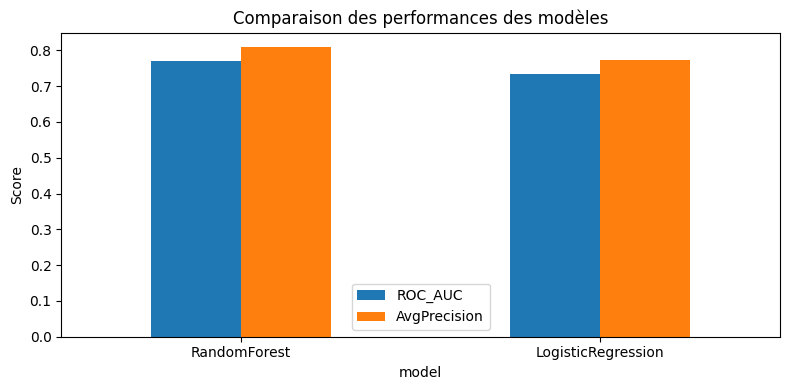

In [ ]:
import matplotlib.pyplot as plt

results_df.plot(
    x="model",
    y=["ROC_AUC", "AvgPrecision"],
    kind="bar",
    figsize=(8, 4)
)
plt.title("Comparaison des performances des modèles")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
#détails
for name, info in details.items():
    print("===", name, "===")
    print("ROC_AUC:", info["roc_auc"])
    print("AvgPrecision:", info["avg_precision"])
    print(info["classification_report"])

=== LogisticRegression ===
ROC_AUC: 0.7325366108417553
AvgPrecision: 0.7723878961536109
              precision    recall  f1-score   support

           0      0.612     0.672     0.641     43872
           1      0.723     0.667     0.694     56128

    accuracy                          0.669    100000
   macro avg      0.667     0.670     0.667    100000
weighted avg      0.674     0.669     0.671    100000

=== RandomForest ===
ROC_AUC: 0.7714044165477996
AvgPrecision: 0.8084411018931636
              precision    recall  f1-score   support

           0      0.589     0.822     0.686     43872
           1      0.799     0.552     0.653     56128

    accuracy                          0.671    100000
   macro avg      0.694     0.687     0.670    100000
weighted avg      0.707     0.671     0.668    100000



### Comparaison des modèles

Le tableau ci-dessus compare les deux modèles prédictifs à l'aide des indicateurs suivants :

- **ROC-AUC**, qui mesure la qualité du classement du modèle ;

- **Précision moyenne**, particulièrement utile pour la classification binaire sur des données déséquilibrées.

Le meilleur modèle est celui qui obtient les scores les plus élevés pour ces indicateurs.

### Limites et pistes d’amélioration

Même si les résultats obtenus sont exploitables, ce pipeline présente certaines limites :

- les variables créées restent relativement simples
- certaines analyses ont dû être allégées pour garder un notebook stable
- le problème du **cold-start** peut apparaître pour les nouveaux utilisateurs ou les produits rares
- l’évaluation repose sur une stratégie de holdout basée sur la dernière commande de chaque utilisateur

Pour aller plus loin, nous pourrions :
- créer des variables temporelles plus riches
- tester d’autres modèles d’ensemble
- améliorer encore la personnalisation des recommandations

### Conclusion ML

Nous avons entraîné deux modèles pour prédire la probabilité de réachat d'un produit :

- Régression logistique
- Forêt aléatoire

Le modèle le plus performant est celui qui présente les valeurs les plus élevées de **ROC-AUC** et de **précision moyenne**.

Ce modèle pourrait aider NextBuy à :
- améliorer les recommandations de produits,
- cibler plus efficacement les promotions,
- et mieux anticiper le comportement d'achat des clients.

Cependant, ce processus présente encore des limitations :

- l'ingénierie des caractéristiques reste relativement simple,

- les utilisateurs ou produits rares peuvent être affectés par un effet de démarrage à froid,

- et l'évaluation repose sur une stratégie de validation croisée basée sur la dernière commande de chaque utilisateur.

Une amélioration future consisterait à ajouter des caractéristiques temporelles plus riches et à tester des modèles d'ensemble plus avancés.